In [3]:
import gymnasium as gym
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches

## Value iterator

In [87]:
def value_iteration(entorno, gamma_p, theta_p):
    
    """
    Implementa el algoritmo Value Iteration (Iteración de Valor).

    Fundamento teórico:
    -------------------
    Aplica la ecuación de Bellman iterativamente sobre todos los estados
    hasta convergencia. En cada barrida actualiza:

        V(s) = max_a { Σ P(s'|s,a) · [R + γ · V(s')] }

    Al converger, extrae la política óptima:
        π*(s) = argmax_a Q(s,a)

    Parámetros:
    -----------
    entorno : gym.Env  — entorno Gym con acceso a entorno.P (modelo del entorno)
    gamma   : float    — factor de descuento (0 < γ ≤ 1)
    theta   : float    — criterio de convergencia (umbral de cambio mínimo)

    Retorna:
    --------
    V       : np.ndarray — función de valor óptima para cada estado
    politica: np.ndarray — política óptima (acción por estado)
    iteraciones: int     — cantidad de iteraciones hasta convergencia
    """

    iteracion = 0
    modelo = entorno.unwrapped.P
    num_estados = entorno.observation_space.n
    num_acciones = entorno.action_space.n
    V = np.zeros(num_estados)
    
    while True:
        delta = 0.0

        for s in range(num_estados):
            valor_anterior = V[s]
            valores_q = np.zeros(num_acciones)

            for a in range(num_acciones):
                for prob, siguiente, recompensa, terminado in modelo[s][a]:
                    valores_q[a] += prob * (recompensa + gamma_p * V[siguiente])

            # Guardamos el máximo valor encontrado entre las acciones
            V[s] = max(valores_q)

            # Calcular el cambio máximo para la condición de parada
            delta = max(delta, abs(valor_anterior - V[s]))

        iteracion += 1
        ##print(f"Iteración {iteracion}: V = {np.round(V, 2)}")

        if delta < theta_p:
            break

    politica_estados = {}
    for s in range(num_estados):
        valores_q = np.zeros(num_acciones)
        for a in range(num_acciones):
            for prob, siguiente, recompensa, terminado in modelo[s][a]:
                valores_q[a] += prob * (recompensa + gamma_p * V[siguiente])

        politica_estados[s] = np.argmax(valores_q)
    return V, politica_estados



def impresion_matriz_v_y_politica(nombre, matriz, policy, dim):
    print(f"Matriz {nombre} de Valores:")
    print(np.round(matriz.reshape(dim, dim), 4))
    print("\nPolítica Óptima:")
    flechas = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    lista_flechas = [flechas[accion] for accion in policy.values()]
    policy_formateado = np.array(lista_flechas).reshape(dim, dim)
    print(policy_formateado)




def graficar_valor_iteration(V_det, V_esto, nombre_archivo, dim):

    if dim == 4:
        MAPA_FROZEN_LAKE = ["SFFF", "FHFH", "FFFH", "HFFG"]
    else:
        MAPA_FROZEN_LAKE = ["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
    fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        f"Value Iteration — Función de Valor V*(s) — FrozenLake {dim}×{dim}",
        fontsize=14,
        fontweight="bold",
    )

    for i, (V, modo) in enumerate([(V_det, "Determinístico"), (V_esto, "Estocástico")]):
        grilla = V.reshape(dim, dim)
        im = ejes[i].imshow(
            grilla,
            cmap="YlOrRd",
            interpolation="nearest",
            vmin=0,
            vmax=max(V.max(), 0.01),
        )
        ejes[i].set_title(f"Modo {modo}", fontsize=12)

        # Anotar cada celda con su valor
        for fila in range(dim):
            for col in range(dim):
                celda = MAPA_FROZEN_LAKE[fila][col]
                texto = celda if celda in ("H", "G") else f"{grilla[fila, col]:.3f}"
                color = "black" if grilla[fila, col] < 0.5 else "white"
                ejes[i].text(
                    col,
                    fila,
                    texto,
                    ha="center",
                    va="center",
                    fontsize=11,
                    color=color,
                    fontweight="bold",
                )

        ejes[i].set_xticks(range(dim))
        ejes[i].set_yticks(range(dim))
        ejes[i].set_xticklabels(range(dim))
        ejes[i].set_yticklabels(range(dim))
        ejes[i].set_xlabel("Columna")
        ejes[i].set_ylabel("Fila")
        plt.colorbar(im, ax=ejes[i], label="V*(s)")

    plt.tight_layout()
    plt.savefig(nombre_archivo)
    plt.show()


def graficar_politica_frozen_lake(
    politica_det, politica_esto, V_det, V_esto, nombre_archivo, dim
):
    if dim == 4:
        MAPA_FROZEN_LAKE = ["SFFF", "FHFH", "FFFH", "HFFG"]
    else:
        MAPA_FROZEN_LAKE = ["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
    SIMBOLOS_ACCIONES = {"frozen_lake": {0: "←", 1: "↓", 2: "→", 3: "↑"}}
    """Visualiza las políticas óptimas de ambos modos como flechas en grilla."""
    simbolos = SIMBOLOS_ACCIONES["frozen_lake"]
    fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Política Óptima — FrozenLake {dim}×{dim}", fontsize=14, fontweight="bold")

    for i, (politica, V, modo) in enumerate(
        [
            (politica_det, V_det, "Determinístico"),
            (politica_esto, V_esto, "Estocástico"),
        ]
    ):
        grilla = V.reshape(dim, dim)
        colores = ["#FFFFFF", "#000000", "#008000"]  # Blanco, Negro y Verde
        cmap_personalizado = mcolors.ListedColormap(colores)
        
        ejes[i].set_title(f"Modo {modo}", fontsize=12)
        
        matriz_fondo = np.zeros((dim, dim))
        for fila in range(dim):
            for col in range(dim):
                rect = patches.Rectangle(
                    (col - 0.5, fila - 0.5), 
                    1, 1, 
                    linewidth=2,       # Grosor del borde negro
                    edgecolor='black', # Color del borde
                    facecolor='none'   # Sin relleno para no tapar el fondo colorido
                )
                ejes[i].add_patch(rect)
                celda = MAPA_FROZEN_LAKE[fila][col]
                if celda == "H":
                    matriz_fondo[fila][col] = 1  # Pintará Rojo
                elif celda == "G":
                    matriz_fondo[fila][col] = 2  # Pintará Azul/Celeste

        # 3. Dibujamos el fondo de color
        ejes[i].imshow(
            matriz_fondo, cmap=cmap_personalizado, vmin=0, vmax=2
        )

        
     
        for fila in range(dim):
            for col in range(dim):
                estado = fila * dim + col
                celda = MAPA_FROZEN_LAKE[fila][col]
                if celda == "H":
                    ejes[i].text(
                        col,
                        fila,
                        "",
                        ha="center",
                        va="center",
                        fontsize=20,
                        color="red",
                        fontweight="bold",
                    )
                elif celda == "G":
                    ejes[i].text(
                        col,
                        fila,
                        "",
                        ha="center",
                        va="center",
                        fontsize=20,
                        color="gold",
                        fontweight="bold",
                    )
                else:
                    flecha = simbolos[politica[estado]]
                    ejes[i].text(
                        col,
                        fila,
                        flecha,
                        ha="center",
                        va="center",
                        fontsize=22,
                        color="black",
                        fontweight="bold",
                    )

        ejes[i].set_xticks(range(dim))
        ejes[i].set_yticks(range(dim))
        ejes[i].set_xticks(np.arange(-0.5, dim, 1), minor=True)
        ejes[i].set_yticks(np.arange(-0.5, dim, 1), minor=True)
        ejes[i].grid(False)
        ejes[i].tick_params(which="both", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(nombre_archivo)
    plt.show()


In [88]:
##codigo para ejecutar frozen lake mas rapido
def ejecutar_frozen_lake(bool_estocastico, dimension):
    if bool_estocastico:
        tipo_matriz = "ESTOCÁSTICO"
    else: 
        tipo_matriz = "DETERMINISTA"
    print(f"FROZEN LAKE {tipo_matriz} {dimension}x{dimension}")
    conjunto_recompensas = []
    suma = 0
    for i in range(30):
        env = gym.make("FrozenLake-v1", is_slippery=bool_estocastico, map_name=f"{dimension}x{dimension}")
        observation, info = env.reset()
        
        episode_over = False
        total_reward = 0
        gamma = 0.99
        theta = 1e-8
        
        matriz_costos_v, politica = value_iteration(env, gamma, theta)
        
        if i==0:
            impresion_matriz_v_y_politica(tipo_matriz, matriz_costos_v, politica, dimension)
        
        estado_actual = observation
        while not episode_over:
            action = politica.get(estado_actual)
            estado_actual, reward, terminated, truncated, info = env.step(action)
        
            total_reward += reward
        
            episode_over = terminated or truncated
            
        print(f"Ejecución {i + 1}: Recompensa = {total_reward}")
        conjunto_recompensas.append(total_reward)
        suma += total_reward
        env.close()
    
    porcentaje_exitos = suma / 30 * 100
    print(f"\nPorcentaje de exitos: {porcentaje_exitos:.4f}%")
    
    return matriz_costos_v, politica, conjunto_recompensas

In [23]:
# Ejecución de Frozen Lake en un entorno Determinista.

FROZEN LAKE DETERMINISTA 4x4
Matriz DETERMINISTA de Valores:
[[0.951  0.9606 0.9703 0.9606]
 [0.9606 0.     0.9801 0.    ]
 [0.9703 0.9801 0.99   0.    ]
 [0.     0.99   1.     0.    ]]

Política Óptima:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]
Ejecución 1: Recompensa = 1
Ejecución 2: Recompensa = 1
Ejecución 3: Recompensa = 1
Ejecución 4: Recompensa = 1
Ejecución 5: Recompensa = 1
Ejecución 6: Recompensa = 1
Ejecución 7: Recompensa = 1
Ejecución 8: Recompensa = 1
Ejecución 9: Recompensa = 1
Ejecución 10: Recompensa = 1
Ejecución 11: Recompensa = 1
Ejecución 12: Recompensa = 1
Ejecución 13: Recompensa = 1
Ejecución 14: Recompensa = 1
Ejecución 15: Recompensa = 1
Ejecución 16: Recompensa = 1
Ejecución 17: Recompensa = 1
Ejecución 18: Recompensa = 1
Ejecución 19: Recompensa = 1
Ejecución 20: Recompensa = 1
Ejecución 21: Recompensa = 1
Ejecución 22: Recompensa = 1
Ejecución 23: Recompensa = 1
Ejecución 24: Recompensa = 1
Ejecución 25: Recompensa = 1
Eje

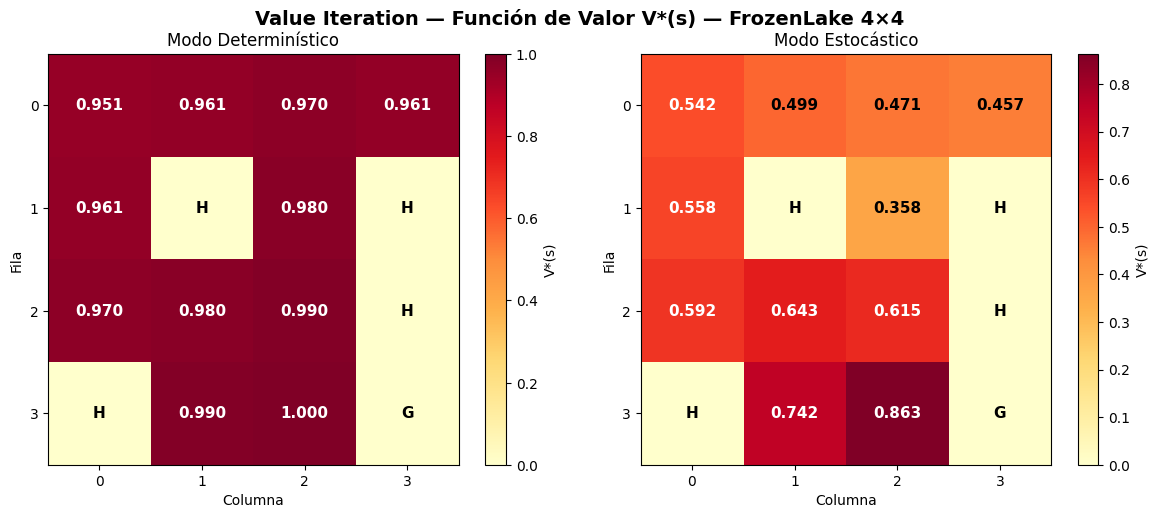

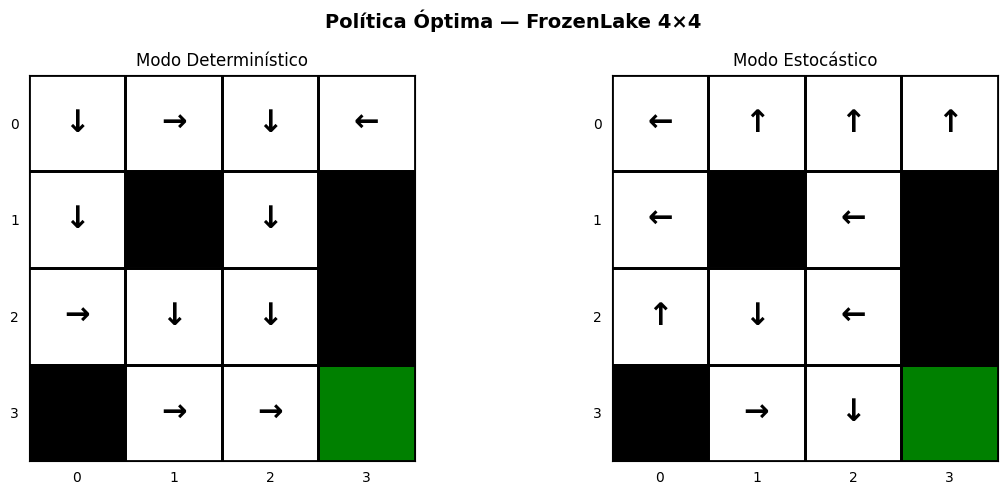

In [24]:
dimension = 4
matriz_costos_v_determinista, politica_determinista, recompensas_determinista = ejecutar_frozen_lake(False, dimension)

print("\n\n\n\n")
matriz_costos_v_estocastica, politica_estocastica, recompensas_estocastica = ejecutar_frozen_lake(True, dimension)

print("\n\n\n\n")
graficar_valor_iteration(matriz_costos_v_determinista, matriz_costos_v_estocastica, "value_iteration_4x4.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, matriz_costos_v_determinista, matriz_costos_v_estocastica,"politica_4x4.png", dimension)

conclusiones

# Ejecución de Frozen Lake en un entorno 8x8.

Ejecución 21: Recompensa = 1
Ejecución 22: Recompensa = 1
Ejecución 23: Recompensa = 1
Ejecución 24: Recompensa = 1
Ejecución 25: Recompensa = 1
Ejecución 26: Recompensa = 1
Ejecución 27: Recompensa = 0
Ejecución 28: Recompensa = 1
Ejecución 29: Recompensa = 0
Ejecución 30: Recompensa = 1

Porcentaje de exitos: 100.0000%





FROZEN LAKE ESTOCÁSTICO 8x8
Matriz ESTOCÁSTICO de Valores:
[[0.4146 0.4272 0.4461 0.4683 0.4924 0.5166 0.5353 0.541 ]
 [0.4117 0.4212 0.4375 0.4584 0.4832 0.5135 0.5458 0.5574]
 [0.3968 0.3938 0.3755 0.     0.4217 0.4938 0.5612 0.5859]
 [0.3693 0.353  0.3065 0.2004 0.3008 0.     0.569  0.6283]
 [0.3327 0.2914 0.1973 0.     0.2893 0.362  0.5348 0.6897]
 [0.3061 0.     0.     0.0863 0.2139 0.2727 0.     0.772 ]
 [0.2889 0.     0.0577 0.0475 0.     0.2505 0.     0.8778]
 [0.2804 0.2008 0.1273 0.     0.2396 0.4864 0.7371 0.    ]]

Política Óptima:
[['↑' '→' '→' '→' '→' '→' '→' '→']
 ['↑' '↑' '↑' '↑' '↑' '→' '→' '↓']
 ['↑' '↑' '←' '←' '→' '↑' '→' '↓']
 ['↑' '↑' '↑' '↓'

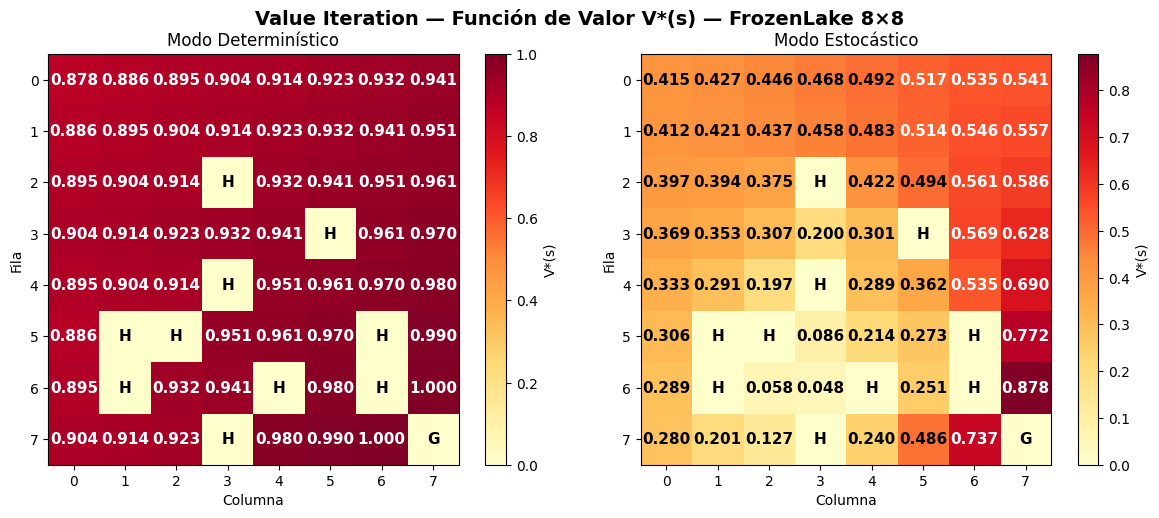

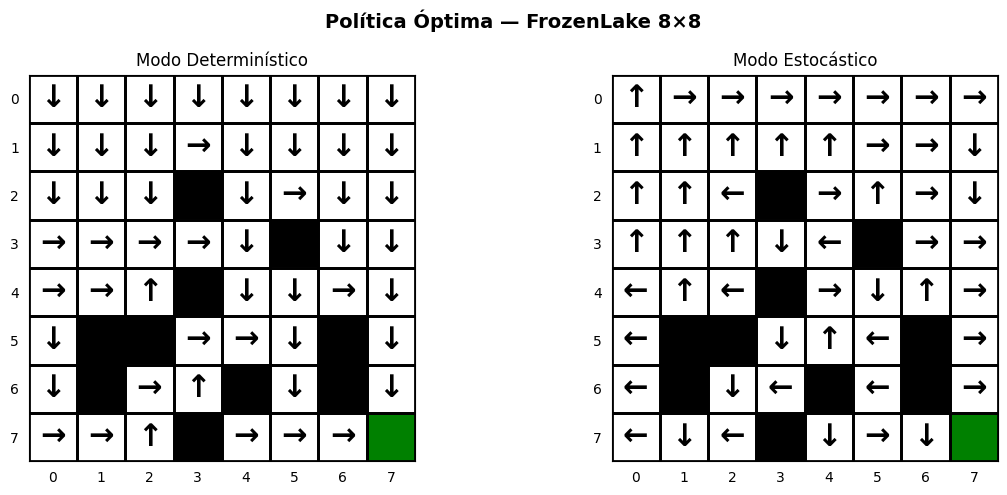

In [25]:
dimension = 8
matriz_costos_v_determinista, politica_determinista, recompensas_determinista = ejecutar_frozen_lake(False, dimension)

print("\n\n\n\n")
matriz_costos_v_estocastica, politica_estocastica, recompensas_estocastica = ejecutar_frozen_lake(True, dimension)

print("\n\n\n\n")
graficar_valor_iteration(matriz_costos_v_determinista, matriz_costos_v_estocastica, "value_iteration_8x8.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, matriz_costos_v_determinista, matriz_costos_v_estocastica,"politica_8x8.png", dimension)

# CART POLE

Tiene dos variantes v0 y v1

el agente tiene que mantenerse con el palo en equilibrio lo mas que pueda
 - en v0 -> 200 pasos y umbral de exito 200
 - en v1 -> 500 pasos y umbal de exito 500

dos formas de recompensa
 1. El agente gana puntos por cada paso que sobrevive
 2. El agente no gana puntos pero pierde si se muere

dos formas de que en teoria tienen el mismo resultado pero estaria interesante comparar ambos

In [83]:
def discretizar(observacion, low, high, k):
    indices = []
    for i in range(len(observacion)):
        val = observacion[i]
        mn = low[i]
        mx = high[i]
        
        # Limitar valor usando python puro (10x más rápido que np.clip)
        val_recortado = mn if val < mn else (mx if val > mx else val)
        
        idx = int((val_recortado - mn) / (mx - mn) * k)
        if idx >= k:
            idx = k - 1
        indices.append(idx)
    return tuple(indices)


In [84]:
def q_learning(entorno, episodios=10000, alfa=0.05, gamma=0.99, epsilon=1.0, decaimiento_epsilon=0.999, 
                es_continuo=False, k=11, low=None, high=None):

    num_acciones = entorno.action_space.n

    if es_continuo:
        dimensiones = len(low)
        Q = np.zeros([k] * dimensiones + [num_acciones])
    else:
        Q = np.zeros((entorno.observation_space.n, num_acciones))

    recompensas_por_episodio = []

    for episodio in range(episodios):
        estado, _ = entorno.reset()
        if es_continuo:
            estado = discretizar(estado, low, high, k)

        recompensa_total = 0
        terminado = False

        while not terminado:
            if np.random.uniform(0, 1) < epsilon:
                accion = entorno.action_space.sample()
            else:
                accion = np.argmax(Q[estado])

            siguiente_estado, recompensa, finalizado, truncado, _ = entorno.step(accion)
            terminado = finalizado or truncado


            if es_continuo:
                siguiente_estado = discretizar(siguiente_estado, low, high, k)

            Q[estado][accion] += alfa * (
                recompensa + gamma * np.max(Q[siguiente_estado]) * (not terminado) - Q[estado][accion]
            )

            estado = siguiente_estado
            recompensa_total += recompensa

        epsilon = max(0.01, epsilon * decaimiento_epsilon)
        recompensas_por_episodio.append(recompensa_total)

    politica = np.argmax(Q, axis=-1)   # axis=-1 sirve para 2D y para N-D

    # eso creo que no hace falta porque no hacemos ningun escenario en 3D
    return Q, politica, recompensas_por_episodio

FROZEN LAKE DETERMINISTA
POLITICA DETERMINISTA: 
 [1 2 1 0 1 0 1 0 2 2 1 0 0 2 2 0]


CUADRO DE PROBABILIDAD DE DECISIONES EN CADA BLOQUE
0 [0.53164605 0.95099005 0.07756403 0.55700494]
1 [0.01816501 0.         0.214039   0.00237228]
2 [2.75842496e-03 4.93231747e-01 2.03284412e-04 1.14951848e-02]
3 [8.31105461e-03 0.00000000e+00 1.47900274e-05 3.65704668e-05]
4 [0.62465005 0.96059601 0.         0.51038191]
5 [0. 0. 0. 0.]
6 [0.         0.86750501 0.         0.02582225]
7 [0. 0. 0. 0.]
8 [0.58851983 0.         0.970299   0.5804599 ]
9 [0.61447447 0.46663236 0.9801     0.        ]
10 [0.58730585 0.99       0.         0.46113322]
11 [0. 0. 0. 0.]
12 [0. 0. 0. 0.]
13 [0.         0.06610407 0.88974256 0.08968906]
14 [0.50533326 0.71951959 1.         0.70777651]
15 [0. 0. 0. 0.]
FROZEN LAKE ESTOCÁSTICO
POLITICA ESTOCÁSTICO: 
 [0 3 1 0 1 0 1 0 2 1 2 0 0 1 1 0]


CUADRO DE PROBABILIDAD DE DECISIONES EN CADA BLOQUE
0 [0.03285135 0.01072238 0.00995081 0.01137781]
1 [3.23561578e-05 4.55631798e-04

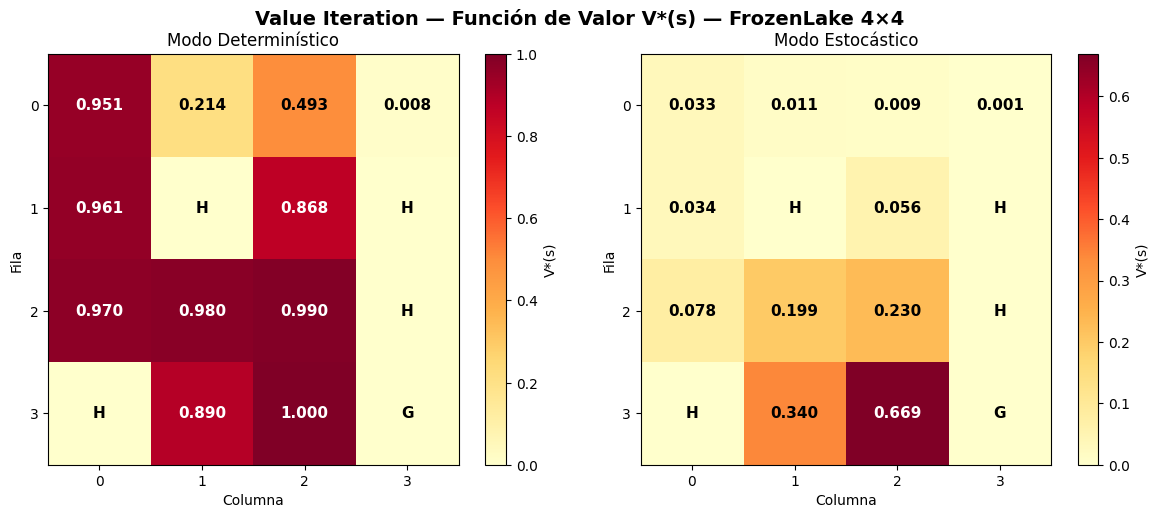

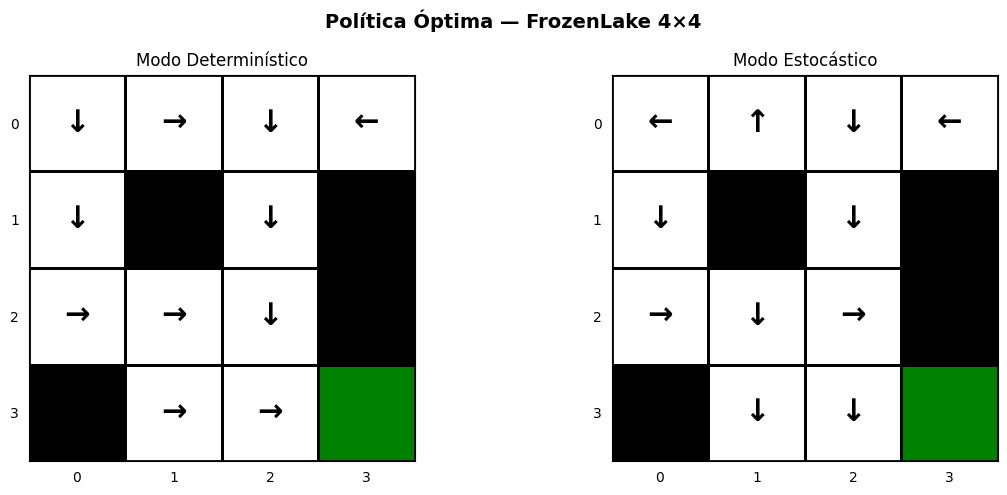

In [ ]:
dimension = 4

def ejecutar_q_learning_frozen_lake(boolean_estocastico, dim):

    if boolean_estocastico: 
        tipo_frozen = "ESTOCÁSTICO" 
    else: 
        tipo_frozen = "DETERMINISTA"
    entorno = gym.make("FrozenLake-v1", is_slippery=boolean_estocastico)
    Q_obt, politica_a_devolver, recompensas = q_learning(
        entorno, es_continuo=False,
        alfa=0.01)

    print(f"FROZEN LAKE {tipo_frozen}")
    print(f"POLITICA {tipo_frozen}: \n",politica_a_devolver)
    print('\n')

    Q_a_devolver = np.zeros(dim*dim)
    print('CUADRO DE PROBABILIDAD DE DECISIONES EN CADA BLOQUE')
    for i,j in enumerate(Q_obt):
        print(f'{i}',j)
        Q_a_devolver[i] = max(j)
    
    return Q_a_devolver, politica_a_devolver, recompensas

Q_determinista, politica_determinista, recompensas_determinista = ejecutar_q_learning_frozen_lake(False, dimension)

Q_estocastica, politica_estocastica, recompensas_estocastica = ejecutar_q_learning_frozen_lake(True, dimension)




graficar_valor_iteration(Q_determinista, Q_estocastica, f"q_value_{dimension}x{dimension}.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, Q_determinista, Q_estocastica,f"q_politica_{dimension}x{dimension}.png", dimension)

In [ ]:
entorno_froz_estocastico = gym.make("FrozenLake-v1", is_slippery=True, map_name="8x8",)
Q_estocastica, politica_final_e, recompensas_totales_e = q_learning(entorno_froz_estocastico, es_continuo=False, episodios=200000, decaimiento_epsilon=0.99997, gamma=0.995)

entorno_froz_determinista = gym.make("FrozenLake-v1", is_slippery=False, map_name="8x8",)
Q_determinista, politica_final_d, recompensas_totales_d = q_learning(entorno_froz_determinista, es_continuo=False, episodios=200000, decaimiento_epsilon=0.99997, gamma=0.995)

# aprendio mal


KeyboardInterrupt: 

Media: 0.30 | Std: 0.46 | Min: 0 | Max: 1
Éxitos: 915/3000 | Tasa de éxito: 0.30 (30.5%)
64
64


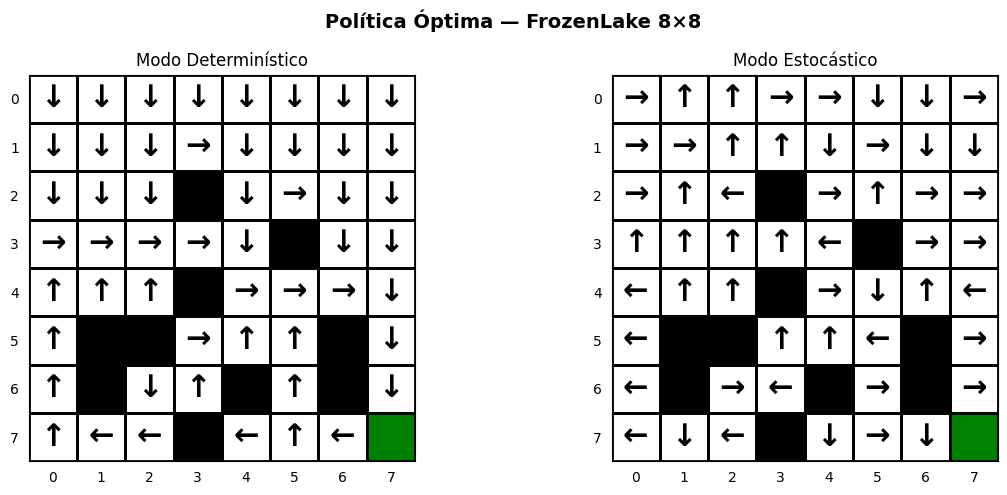

In [ ]:
env = gym.make ("FrozenLake-v1", is_slippery=True ,map_name="8x8")
recompensas = []
completados = 0
num_episodios = 3000
dimension_2=8
for _ in range(num_episodios):
    estado, _ = env.reset()
    terminado = False
    r = 0
    while not terminado:
        accion = politica_final_e[estado]
        estado, recompensa, fin, trunc, _ = env.step(accion)
        terminado = fin or trunc

        r += recompensa
    recompensas.append(r)
    if r > 0: # o también: if r == 1
        completados += 1
# Métricas generales de recompensas
print(f"Media: {np.mean(recompensas):.2f} | Std: {np.std(recompensas):.2f} | Min: {min(recompensas)} | Max: {max(recompensas)}")
# Calcular e imprimir la tasa de éxito
tasa_exito = completados / num_episodios
porcentaje_exito = tasa_exito * 100
print(f"Éxitos: {completados}/{num_episodios} | Tasa de éxito: {tasa_exito:.2f} ({porcentaje_exito:.1f}%)")

print(len(politica_final_d))
print(len(politica_final_e))


V_determinista = np.max(Q_determinista, axis=-1)
V_estocastica = np.max(Q_estocastica, axis=-1)

graficar_valor_iteration(V_determinista, V_estocastica, f"q_value_{dimension}x{dimension}.png", dimension)
graficar_politica_frozen_lake(politica_final_d, politica_final_e, V_determinista, V_estocastica,f"q_politica_{dimension_2}x{dimension_2}.png", dimension_2)

In [ ]:
env = gym.make ("FrozenLake-v1",is_slippery=True, render_mode='human', map_name="8x8")
recompensas = []
estado, _ = env.reset()

terminado = False
r = 0
while not terminado:
        accion = politica_final_e[estado]
        estado, recompensa, fin, trunc, _ = env.step(accion)
        terminado = fin or trunc
        r += recompensa

env.close()

In [78]:
# MountainCar: funciona sin tocar nada, los límites son finitos
# entorno = gym.make("MountainCar-v0")
# Q, politica, recompensas = apren_q(entorno, es_continuo=True)

# CartPole: pasás límites manuales para las variables con inf
low=np.array([-4.8, -3.5, -0.418, -3.5])
high=np.array([ 4.8,  3.5,  0.418,  3.5])
entorno = gym.make("CartPole-v1", sutton_barto_reward=True)
Q, politica, recompensas = q_learning(
    entorno, es_continuo=True,
    low=low,
    high=high,
    k=11,
)



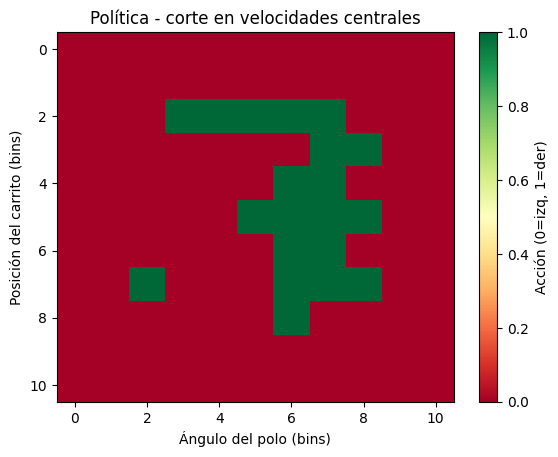

In [80]:

plt.imshow(politica[:, 5, :, 5], cmap='RdYlGn', aspect='auto')
plt.xlabel("Ángulo del polo (bins)")
plt.ylabel("Posición del carrito (bins)")
plt.title("Política - corte en velocidades centrales")
plt.colorbar(label="Acción (0=izq, 1=der)")
plt.show()

In [81]:

env = gym.make ("CartPole-v1" )
recompensas = []
for _ in range(20):
    obs, _ = env.reset()
    estado = discretizar(obs, low=low, high=high, k=11)
    terminado = False
    r = 0
    while not terminado:
        accion = politica[estado]
        obs, recompensa, fin, trunc, _ = env.step(accion)
        terminado = fin or trunc
        estado = discretizar(obs, low=low, high=high, k=11)
        r += recompensa
    recompensas.append(r)

print(f"Media: {np.mean(recompensas):.1f} | Std: {np.std(recompensas):.1f} | Min: {min(recompensas)} | Max: {max(recompensas)}")

Media: 500.0 | Std: 0.0 | Min: 500.0 | Max: 500.0


In [82]:
import time

env_visual = gym.make("CartPole-v1", render_mode="human",max_episode_steps=500)
observacion, info = env_visual.reset()
# 2. Discretizar el estado inicial
estado = discretizar(observacion,low=low,high=high,k=11,)
terminado = False
recompensa_prueba = 0

iteracion = 0
while not terminado and iteracion < 500:
    time.sleep(0.03)
    # 3. Elegir la mejor acción según la política aprendida para este estado discretizado
    accion = politica[estado] 
    
    # 4. Ejecutar la acción
    siguiente_observacion, recompensa, finalizado, truncado, _ = env_visual.step(accion)
    terminado = finalizado or truncado
    recompensa_prueba += recompensa
    
    # 5. Discretizar el nuevo estado para el siguiente paso
    estado = discretizar(siguiente_observacion,low=low,high=high,k=11)
print(f"Recompensa obtenida en la prueba visual: {recompensa_prueba}")
env_visual.close()

Recompensa obtenida en la prueba visual: 500.0


EXTRA DE PRUEBA


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1800, 1200) to (1808, 1200) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
